# Simuleringsoppgåve
## Oppgåve 5.1

**Rapport del 1:**

I dette programmet har eg laga ei simulering som ser over salet til ein butikk med fire produkt i 30 dagar. Simuleringa viser både produkta med ordinær pris, og med tilbod. Med produkt på tilbud følger også en høyere salgsrate som følge av en mer attraktiv pris. Etter at programmet har simulert sal med og utan tilbod, samanliknar dei også desse to for å sjå kor mykje butikken tener, og kor mykje dei sel av kvart produkt. 

Det første vi gjer er å importere matplotlib.pyplot for å laga grafane som viser resultatet. Nympy har vi teke med for å genrerer tilfeldige tall, og hjelpe oss med å håndtere lister. Det neste vi er nøydd til å gjere er å definere variablane våra både for å gjere programmet enklare å forstå, og til å bruke i resten av programmet vårt. Funksjonen vår har med et parameter tilbod=False. Dette er teke med slik av vi kan kjøre programmet utan tilbod, med mindre vi spesifiserar noko anna, som vi kjem til å gjere seinare i programmet. I funksjonen har vi også med total_omsetning som representerar inntekta vår som startar på 0. Total_sal viser kor mykje av kvart produkt som selges. I det neste steget har eg tatt med to løkker som går gjennom dei 30 dagane våra og dei 10 kundane per dag. Dette gjer vi for å registrere salet over tid. I tilegg har vi teke med budsjett der numpy tek føre seg eit tilfeldig tal, der gjennomsnittet er 500 med eit standardavvik på 150........fortsettelse følger


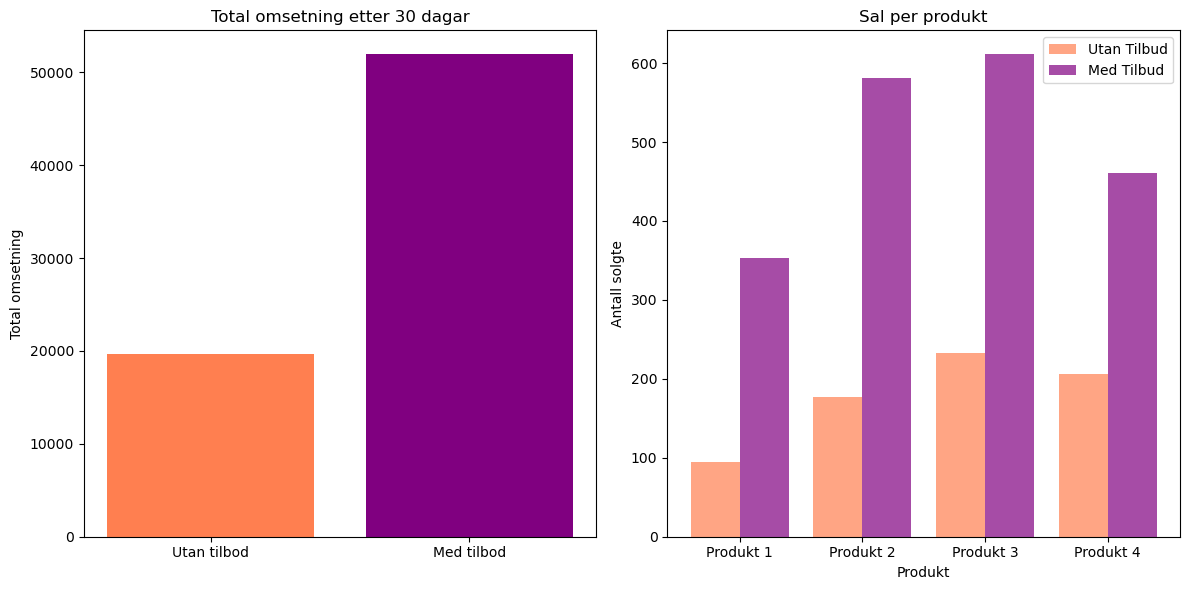

Total omsetning utan tilbod: 19720
Total omsetning med tilbod: 51920
Totalt sal per produkt utan tilbod: [ 95. 177. 233. 206.]
Totalt sal per produkt med tilbod: [353. 581. 611. 461.]


In [47]:
import matplotlib.pyplot as plt
import numpy as np

dagar = 30
kundar_per_dag = 10
produkt = 4

prisar = [10,20,30,40] #Vanlege prisar
salsrate = [0.1, 0.2, 0.3, 0.4]
tilbudsrate = 0.5


def sal(tilbod=False):
    total_omsetning = 0
    total_sal = np.zeros(produkt)

    for _ in range(dagar):
        for _ in range(kundar_per_dag):
            budsjett = np.random.normal(500,150)
            
            while budsjett > 0:
                produkt_kjøpt = False

                for i in range(produkt):
                    if tilbod:
                        salsrate_justert = salsrate[i] + (salsrate[i]* tilbudsrate)
                    else:
                        salsrate_justert = salsrate[i]
                        
                    if np.random.rand() < salsrate_justert and budsjett >= prisar[i]:
                        total_sal[i] += 1
                        total_omsetning += prisar[i]
                        budsjett -= prisar[i]
                        produkt_kjøpt = True
                        break
                        
                if not produkt_kjøpt:
                    break
                        

    return total_sal, total_omsetning

total_sal_utan_tilbod, omsetning_utan_tilbod = sal(tilbod=False)
total_sal_tilbud, omsetning_med_tilbod = sal(tilbod=True)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.bar(["Utan tilbod", "Med tilbod"], [omsetning_utan_tilbod, omsetning_med_tilbod], color=["coral", "purple"])
plt.ylabel("Total omsetning")
plt.title("Total omsetning etter 30 dagar")

plt.subplot(1, 2, 2)
x = np.arange(produkt)
plt.bar(x - 0.2, total_sal_utan_tilbod, width=0.4, color="coral", alpha=0.7, label="Utan Tilbud")
plt.bar(x + 0.2, total_sal_tilbud ,width=0.4, color="purple", alpha=0.7, label='Med Tilbud')
plt.xlabel("Produkt")
plt.ylabel("Antall solgte")
plt.title("Sal per produkt")
plt.xticks(x, [f"Produkt {i + 1}" for i in range(produkt)])
plt.legend()

plt.tight_layout()
plt.show()

print(f"Total omsetning utan tilbod: {omsetning_utan_tilbod}")
print(f"Total omsetning med tilbod: {omsetning_med_tilbod}")
print(f"Totalt sal per produkt utan tilbod: {total_sal_utan_tilbod}")
print(f"Totalt sal per produkt med tilbod: {total_sal_tilbud}")